<a href="https://colab.research.google.com/github/nipuninduwaraedu/SE4050-Assignment-/blob/member3-model3/Member3_Model3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
FILE_PATH = '/content/prepared_har_data (2).npz.zip'
print(f"File path set to: {FILE_PATH}")

File path set to: /content/prepared_har_data (2).npz.zip


In [ ]:
import zipfile
import os

# Ensure the output directory exists
output_dir = '/content/unzipped_data'
os.makedirs(output_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"File '{FILE_PATH}' unzipped to '{output_dir}'.")

File '/content/prepared_har_data (2).npz.zip' unzipped to '/content/unzipped_data'.


In [ ]:
import numpy as np
import os

# Define the directory where the files were unzipped
# This assumes 'output_dir' is defined in a previous cell, or we can hardcode it if necessary.
# For robustness, we will ensure it's defined or use a known value.
# If output_dir was from a previous cell, it's already in the kernel state. Let's use it.

# Construct the full paths to the .npy files
X_train_path = os.path.join(output_dir, "X_train.npy")
y_train_path = os.path.join(output_dir, "y_train.npy")

X_validation_path = os.path.join(output_dir, "X_validation.npy")
y_validation_path = os.path.join(output_dir, "y_validation.npy")

X_test_path = os.path.join(output_dir, "X_test.npy")
y_test_path = os.path.join(output_dir, "y_test.npy")

activity_names_path = os.path.join(output_dir, "activity_names.npy")


X_train = np.load(X_train_path)
y_train = np.load(y_train_path)

X_validation = np.load(X_validation_path)
y_validation = np.load(y_validation_path)

X_test = np.load(X_test_path)
y_test = np.load(y_test_path)

activity_names = np.load(activity_names_path)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Activities:", activity_names)

X_train: (5551, 128, 9)
y_train: (5551,)
X_validation: (1801, 128, 9)
y_validation: (1801,)
X_test: (2947, 128, 9)
y_test: (2947,)
Activities: ['WALKING' 'WALKING_UPSTAIRS' 'WALKING_DOWNSTAIRS' 'SITTING' 'STANDING'
 'LAYING']


In [ ]:
import numpy as np

print("Unique training labels:", np.unique(y_train))
print("Unique validation labels:", np.unique(y_validation))
print("Unique test labels:", np.unique(y_test))

Unique training labels: [0 1 2 3 4 5]
Unique validation labels: [0 1 2 3 4 5]
Unique test labels: [0 1 2 3 4 5]


In [ ]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(activity_names[label], ":", count)

WALKING : 888
WALKING_UPSTAIRS : 797
WALKING_DOWNSTAIRS : 744
SITTING : 993
STANDING : 1053
LAYING : 1076


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(128, 9), return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(6, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 64)        │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,614 (127.40 KB)

 Trainable params: 32,614 (127.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
import time

start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=64,
    verbose=1
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.5758 - loss: 1.0916 - val_accuracy: 0.7807 - val_loss: 0.6145
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.7869 - loss: 0.5376 - val_accuracy: 0.9051 - val_loss: 0.3518
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.8914 - loss: 0.3312 - val_accuracy: 0.9517 - val_loss: 0.2217
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.8943 - loss: 0.3048 - val_accuracy: 0.9295 - val_loss: 0.2596
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9215 - loss: 0.1950 - val_accuracy: 0.9750 - val_loss: 0.1464
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.9310 - loss: 0.1728 - val_accuracy: 0.9739 - val_loss: 0.1417
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9351 - loss: 0.1565 - val_accuracy: 0.9745 - val_loss: 0.1186
Epoch 8/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.9362 - loss: 0.1502 - val_accuracy: 0.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9452 - loss: 0.1376 - val_accuracy: 0.9750 - val_loss: 0.1916
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.9463 - loss: 0.1308 - val_accuracy: 0.9956 - val_loss: 0.0665
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.9474 - loss: 0.1292 - val_accuracy: 0.9745 - val_loss: 0.1147
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9470 - loss: 0.1360 - val_accuracy: 0.9761 - val_loss: 0.2039
Epoch 5/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.9447 - loss: 0.1388 - val_accuracy: 0.9756 - val_loss: 0.1944
Epoch 6/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.9497 - loss: 0.1204 - val_accuracy: 0.9778 - val_loss: 0.1863
Epoch 7/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9490 - loss: 0.1100 - val_accuracy: 0.9733 - val_loss: 0.1918
Training time: 66.18 seconds


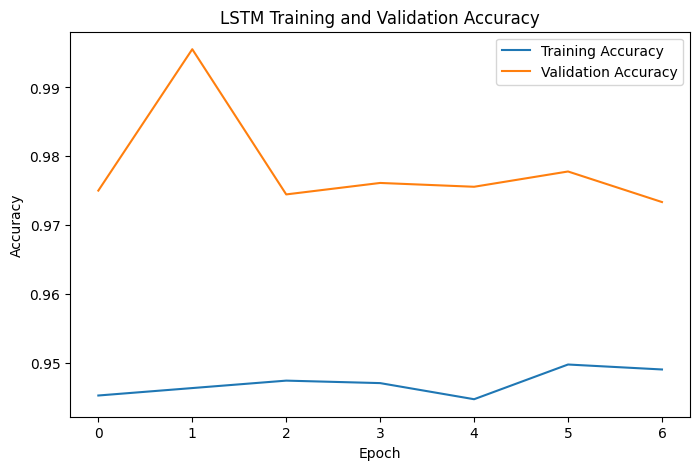

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.show()

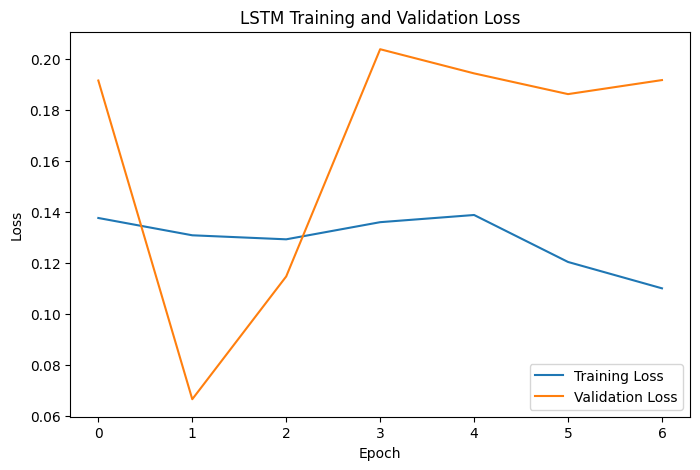

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

In [19]:
plt.savefig("training_curve.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [20]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.3656788170337677
Test Accuracy: 0.9168646335601807


In [21]:
y_probability = model.predict(X_test)

y_pred = np.argmax(y_probability, axis=1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [23]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9168646080760094
Precision: 0.9169758009263915
Recall   : 0.9168646080760094
F1 Score : 0.9161522536269417


In [24]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=activity_names
    )
)

                    precision    recall  f1-score   support

           WALKING       0.99      0.92      0.96       496
  WALKING_UPSTAIRS       0.92      0.98      0.95       471
WALKING_DOWNSTAIRS       0.91      0.99      0.95       420
           SITTING       0.83      0.78      0.80       491
          STANDING       0.84      0.85      0.85       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



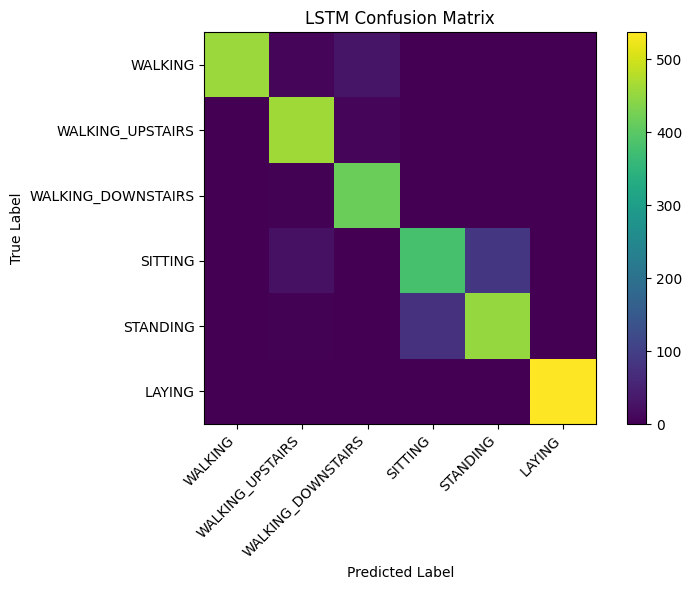

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(activity_names)),
    activity_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(activity_names)),
    activity_names
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [26]:
plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [27]:
total_params = model.count_params()

print("Total Parameters:", total_params)

Total Parameters: 32614


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 64)        │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,844 (382.21 KB)

 Trainable params: 32,614 (127.40 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 65,230 (254.81 KB)

In [29]:
import pandas as pd

metrics = pd.DataFrame({
    "Model": ["LSTM"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "Training_Time_Seconds": [training_time],
    "Parameters": [total_params]
})

metrics.to_csv(
    "metrics.csv",
    index=False
)

metrics

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time_Seconds,Parameters
0,LSTM,0.916865,0.916976,0.916865,0.916152,66.179075,32614
